# 01 — Preprocessing & Exploratory Data Analysis
**Project:** ACC Biomarker Discovery via XAI  
**Thesis:** Bachelor's — Biomedical Informatics  

This notebook implements the full preprocessing pipeline specified in `project_context.md`:
1. Data loading & quality assessment
2. ENSEMBL ID cleaning
3. Log2(FPKM + 1) transformation
4. Low-variance gene filtering (CV < 0.1)
5. Feature selection — top 2,000 most variable genes
6. Molecular subtype derivation via k-means (k=2 on PCA)
7. Class imbalance handling (SMOTE if > 60:40)
8. Z-score normalization
9. Exploratory analysis plots

**Deliverables:** Clean, normalized feature matrix + target labels saved to `data/processed/`.

## 1. Setup & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
np.random.seed(SEED)

# --- Paths (relative to project root) ---
ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path("..").resolve()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {ROOT}")
print(f"Raw data dir : {RAW_DIR}")
print(f"Output dir   : {PROCESSED_DIR}")

Project root : E:\Research Paper\ACC
Raw data dir : E:\Research Paper\ACC\data\raw
Output dir   : E:\Research Paper\ACC\data\processed


## 2. Data Loading

In [2]:
# --- 2a. Gene Expression (STAR — FPKM) ---
expr_raw = pd.read_csv(RAW_DIR / "TCGA-ACC.star_fpkm.tsv.gz", sep="\t", index_col=0)
expr_raw.index.name = "Ensembl_ID"

print("=== Raw Expression Matrix ===")
print(f"  Genes   : {expr_raw.shape[0]:,}")
print(f"  Samples : {expr_raw.shape[1]}")
print(f"  NaN count: {expr_raw.isna().sum().sum()}")
print(f"  Value range: [{expr_raw.values.min():.4f}, {expr_raw.values.max():.4f}]")
expr_raw.head(3)

=== Raw Expression Matrix ===
  Genes   : 60,660
  Samples : 79
  NaN count: 0
  Value range: [0.0000, 17.4568]


,TCGA-OR-A5K2-01A,TCGA-OR-A5LN-01A,TCGA-OR-A5JG-01A,TCGA-OR-A5KX-01A,TCGA-OR-A5LR-01A,TCGA-OR-A5JI-01A,TCGA-PK-A5HB-01A,TCGA-OR-A5JK-01A,TCGA-OU-A5PI-01A,TCGA-OR-A5K5-01A,...,TCGA-PK-A5H9-01A,TCGA-OR-A5JS-01A,TCGA-OR-A5JJ-01A,TCGA-OR-A5JM-01A,TCGA-P6-A5OF-01A,TCGA-PA-A5YG-01A,TCGA-OR-A5JY-01A,TCGA-OR-A5J5-01A,TCGA-OR-A5LD-01A,TCGA-OR-A5J6-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,2.559320,2.550334,3.193425,3.515485,4.447163,3.629205,3.670546,3.138110,2.714553,2.852898,...,3.250977,3.916333,4.016577,3.481144,3.256709,3.748000,4.077944,3.132182,2.102457,2.812272
ENSG00000000005.6,0.316957,0.114234,0.291250,0.042504,0.065710,0.024462,0.110363,0.098824,0.133300,0.294900,...,0.240864,0.054084,0.020769,0.082021,0.259303,0.086240,0.115033,0.000000,0.041103,1.827372
ENSG00000000419.13,5.655483,4.103556,5.701194,5.571376,5.688152,4.506329,5.708913,4.944024,5.880139,5.164179,...,4.532373,5.677139,6.413283,5.435762,5.804017,5.287483,5.372872,3.181564,3.007052,5.659708


In [3]:
# --- 2b. Clinical / Phenotype Data ---
clin_raw = pd.read_csv(RAW_DIR / "TCGA-ACC.clinical.tsv.gz", sep="\t")

print("=== Clinical Data ===")
print(f"  Records : {clin_raw.shape[0]}")
print(f"  Features: {clin_raw.shape[1]}")

# Key clinical columns for downstream survival analysis
KEY_CLIN_COLS = [
    "sample", "vital_status.demographic", "days_to_death.demographic",
    "days_to_last_follow_up.diagnoses", "age_at_diagnosis.diagnoses",
    "gender.demographic", "ajcc_pathologic_stage.diagnoses",
]
clin_raw[KEY_CLIN_COLS].head(5)

=== Clinical Data ===
  Records : 92
  Features: 82


,sample,vital_status.demographic,days_to_death.demographic,days_to_last_follow_up.diagnoses,age_at_diagnosis.diagnoses,gender.demographic,ajcc_pathologic_stage.diagnoses
0,TCGA-OR-A5LF-01A,Dead,445.0,NaN,27179,female,Stage III
1,TCGA-OR-A5KB-01A,Alive,NaN,741.0,22550,female,Stage II
2,TCGA-OR-A5JH-01A,Alive,NaN,2110.0,11994,female,Stage II
3,TCGA-PK-A5HC-01A,Alive,NaN,679.0,16182,female,Stage III
4,TCGA-OR-A5L2-01A,Dead,1852.0,NaN,30535,female,Stage II


In [4]:
# --- 2c. Sample Overlap ---
expr_samples = set(expr_raw.columns)
clin_samples = set(clin_raw["sample"].values)
shared = sorted(expr_samples & clin_samples)

print(f"Expression-only : {len(expr_samples - clin_samples)}")
print(f"Clinical-only   : {len(clin_samples - expr_samples)}")
print(f"Shared samples  : {len(shared)}")

# Keep only shared samples (maintain expression column order)
expr = expr_raw[[s for s in expr_raw.columns if s in clin_samples]].copy()
clin = clin_raw[clin_raw["sample"].isin(expr_samples)].copy()
# Drop duplicate sample rows (some TCGA samples have multiple clinical entries)
clin = clin.drop_duplicates(subset="sample", keep="first")
clin = clin.set_index("sample").loc[expr.columns]

print(f"\nFiltered expression : {expr.shape}")
print(f"Filtered clinical   : {clin.shape}")

Expression-only : 0
Clinical-only   : 13
Shared samples  : 79

Filtered expression : (60660, 79)
Filtered clinical   : (79, 81)


## 3. ENSEMBL ID Cleaning
Strip version suffixes (e.g., `ENSG00000000003.15` → `ENSG00000000003`).
If duplicates arise after stripping, keep the gene with highest mean expression.

In [5]:
# Strip version suffix
expr.index = expr.index.str.split(".").str[0]

# Handle potential duplicates
n_before = expr.shape[0]
dup_mask = expr.index.duplicated(keep=False)
if dup_mask.any():
    print(f"  Found {dup_mask.sum()} duplicate ENSEMBL IDs after stripping versions.")
    # Keep the row with the highest mean expression for each duplicate
    expr["_mean"] = expr.mean(axis=1)
    expr = expr.sort_values("_mean", ascending=False)
    expr = expr[~expr.index.duplicated(keep="first")]
    expr = expr.drop(columns=["_mean"])
    print(f"  Resolved: {n_before} → {expr.shape[0]} genes")
else:
    print(f"  No duplicate ENSEMBL IDs. Total genes: {expr.shape[0]}")

  Found 88 duplicate ENSEMBL IDs after stripping versions.


  Resolved: 60660 → 60616 genes


## 4. Log2(FPKM + 1) Transformation
Compresses the dynamic range and stabilizes variance across genes.

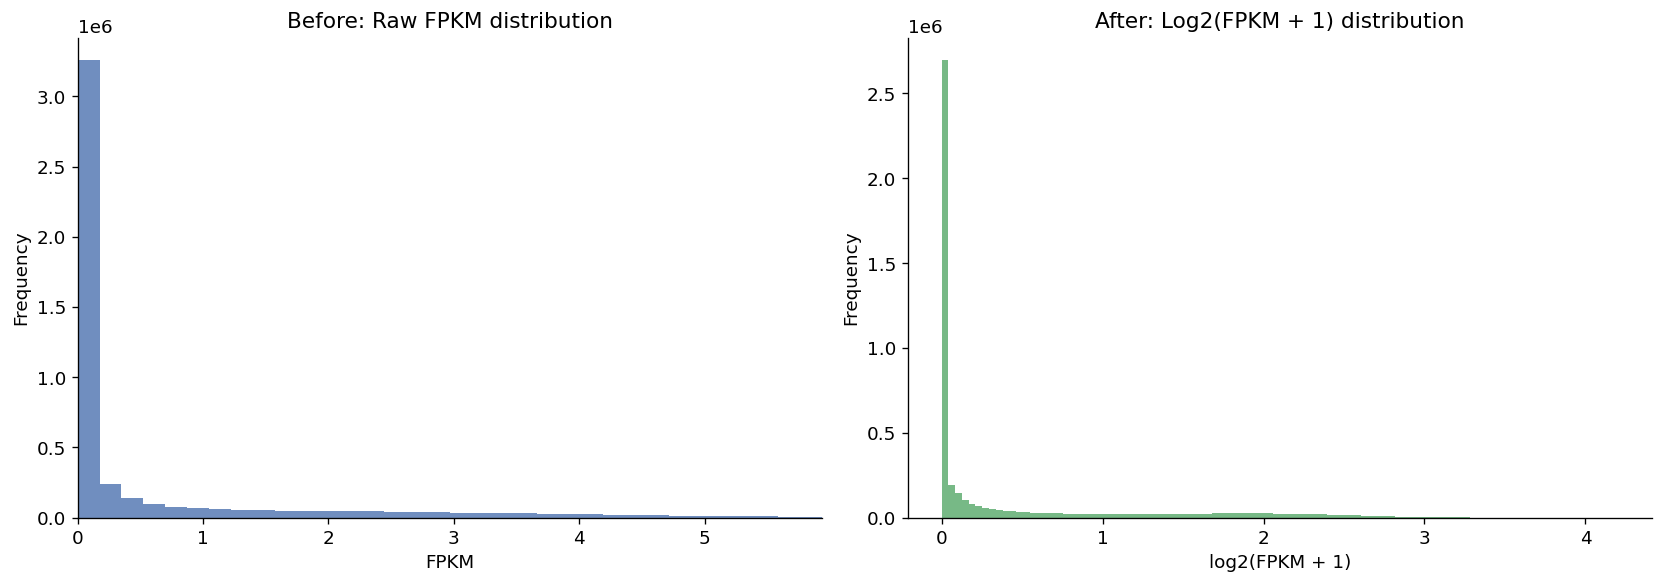

Log2 value range: [0.000, 4.206]


In [6]:
expr_log = np.log2(expr + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(expr.values.flatten(), bins=100, color="#4C72B0", edgecolor="none", alpha=0.8)
axes[0].set(title="Before: Raw FPKM distribution", xlabel="FPKM", ylabel="Frequency")
axes[0].set_xlim(0, np.percentile(expr.values.flatten(), 99))

axes[1].hist(expr_log.values.flatten(), bins=100, color="#55A868", edgecolor="none", alpha=0.8)
axes[1].set(title="After: Log2(FPKM + 1) distribution", xlabel="log2(FPKM + 1)", ylabel="Frequency")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "log2_transform_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Log2 value range: [{expr_log.values.min():.3f}, {expr_log.values.max():.3f}]")

## 5. Low-Variance Gene Filtering (CV < 0.1)
Remove genes with Coefficient of Variation < 0.1 across all samples.
This eliminates housekeeping / near-constant genes that carry no discriminative signal.

Genes before CV filter : 60,616
Genes removed (CV<0.1) : 10,909
Genes retained         : 49,707


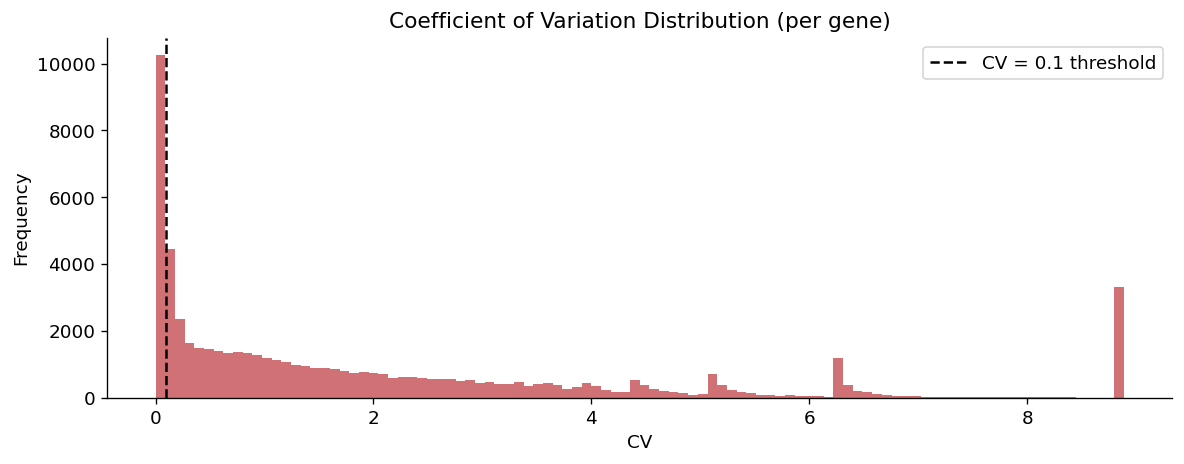

In [7]:
gene_means = expr_log.mean(axis=1)
gene_stds = expr_log.std(axis=1)

# Avoid division by zero for genes with zero mean
cv = gene_stds / gene_means.replace(0, np.nan)
cv = cv.fillna(0)

high_var_mask = cv >= 0.1
n_removed = (~high_var_mask).sum()

print(f"Genes before CV filter : {expr_log.shape[0]:,}")
print(f"Genes removed (CV<0.1) : {n_removed:,}")
print(f"Genes retained         : {high_var_mask.sum():,}")

expr_filtered = expr_log.loc[high_var_mask].copy()

# CV distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cv.values, bins=100, color="#C44E52", edgecolor="none", alpha=0.8)
ax.axvline(0.1, color="black", linestyle="--", linewidth=1.5, label="CV = 0.1 threshold")
ax.set(title="Coefficient of Variation Distribution (per gene)", xlabel="CV", ylabel="Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cv_filter_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Selection — Top 2,000 Most Variable Genes
Rank remaining genes by variance and select top 2,000.

Selected top 2000 genes by variance.
Feature matrix shape: (2000, 79)  (genes × samples)


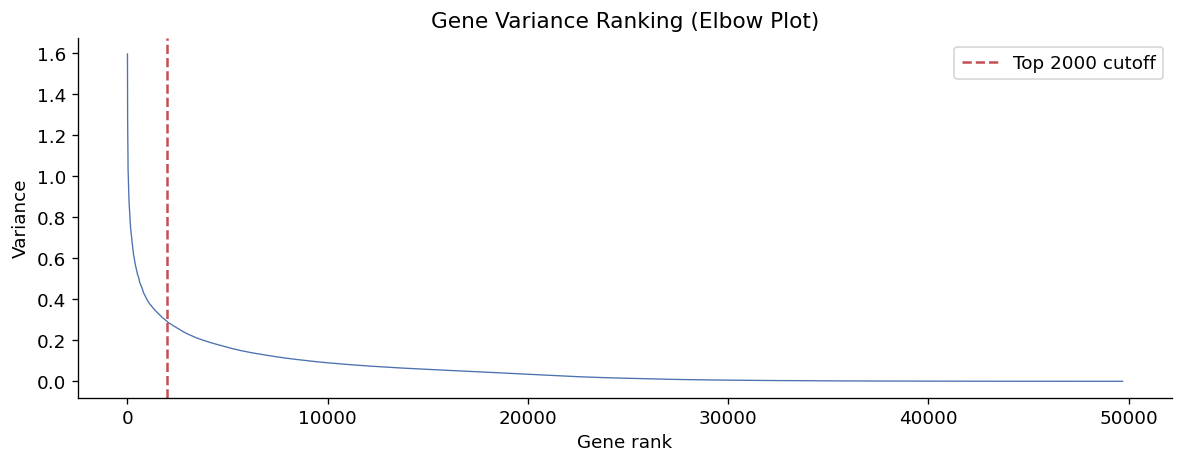

In [8]:
TOP_K = 2000
gene_var = expr_filtered.var(axis=1).sort_values(ascending=False)

if expr_filtered.shape[0] <= TOP_K:
    print(f"Only {expr_filtered.shape[0]} genes remain — keeping all (< {TOP_K}).")
    expr_top = expr_filtered.copy()
else:
    top_genes = gene_var.head(TOP_K).index
    expr_top = expr_filtered.loc[top_genes].copy()
    print(f"Selected top {TOP_K} genes by variance.")

print(f"Feature matrix shape: {expr_top.shape}  (genes × samples)")

# Variance elbow plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(gene_var) + 1), gene_var.values, color="#4C72B0", linewidth=0.8)
if expr_filtered.shape[0] > TOP_K:
    ax.axvline(TOP_K, color="#C44E52", linestyle="--", linewidth=1.5, label=f"Top {TOP_K} cutoff")
ax.set(title="Gene Variance Ranking (Elbow Plot)", xlabel="Gene rank", ylabel="Variance")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "variance_elbow_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Molecular Subtype Derivation (k-Means, k=2 on PCA)
The GDC clinical matrix does not include published molecular subtypes.
Following the project baseline, we derive **Cluster 1 vs Cluster 2** via
k-means (k=2) on the first principal components of the filtered expression data.

PCA components retained : 52
Cumulative variance     : 90.48%


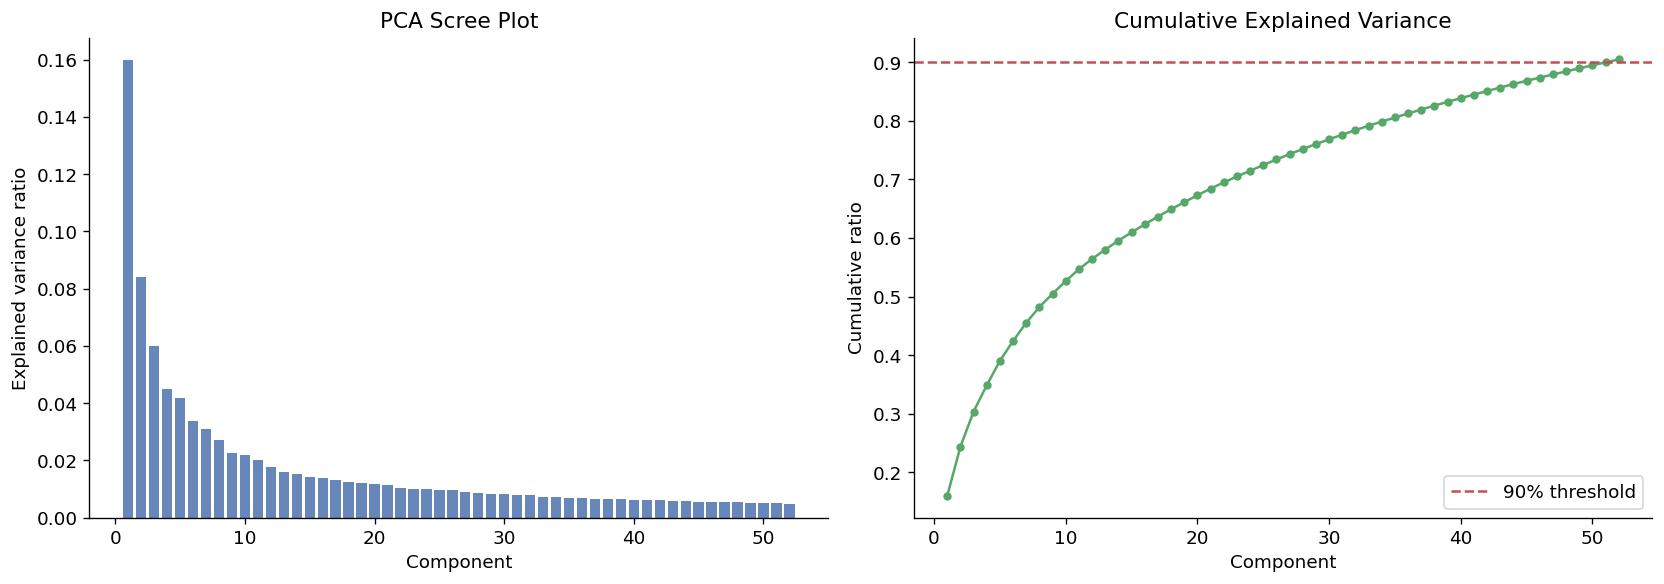

In [9]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Transpose: samples (rows) × genes (columns) for PCA
X_pca_input = expr_top.T.values  # (79, 2000)

# Fit PCA — retain components explaining ≥ 90% variance
pca = PCA(n_components=0.90, random_state=SEED)
X_pca = pca.fit_transform(X_pca_input)

print(f"PCA components retained : {pca.n_components_}")
print(f"Cumulative variance     : {pca.explained_variance_ratio_.sum():.2%}")

# --- Scree plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_,
            color="#4C72B0", edgecolor="none", alpha=0.85)
axes[0].set(title="PCA Scree Plot", xlabel="Component", ylabel="Explained variance ratio")

cum_var = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, pca.n_components_ + 1), cum_var, "-o", color="#55A868", markersize=4)
axes[1].axhline(0.90, color="#C44E52", linestyle="--", label="90% threshold")
axes[1].set(title="Cumulative Explained Variance", xlabel="Component", ylabel="Cumulative ratio")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

Silhouette score (k=2): 0.1313

Class distribution:
subtype
Cluster_2    45
Cluster_1    34
Name: count, dtype: int64


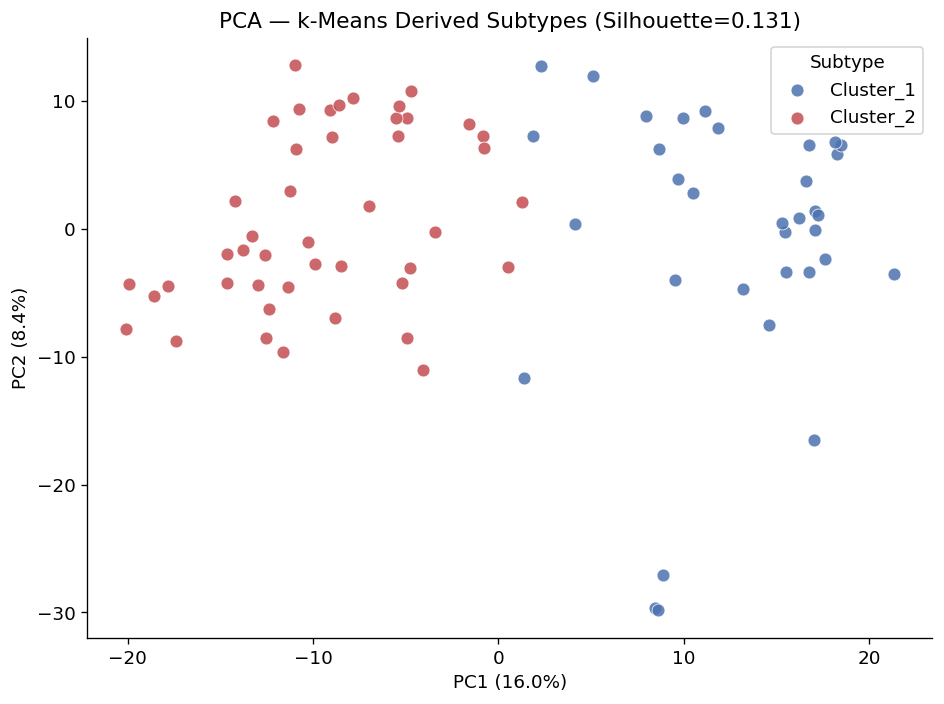

In [10]:
# --- k-Means Clustering (k=2) ---
kmeans = KMeans(n_clusters=2, n_init=50, max_iter=500, random_state=SEED)
cluster_labels = kmeans.fit_predict(X_pca)

sil_score = silhouette_score(X_pca, cluster_labels)
print(f"Silhouette score (k=2): {sil_score:.4f}")

# Map labels to meaningful names
label_map = {0: "Cluster_1", 1: "Cluster_2"}
y = pd.Series(cluster_labels, index=expr_top.columns, name="subtype")
y_named = y.map(label_map)

print(f"\nClass distribution:")
print(y_named.value_counts())

# --- PCA scatter by cluster ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Cluster_1": "#4C72B0", "Cluster_2": "#C44E52"}
for label, color in colors.items():
    mask = y_named.values == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=label, s=60, edgecolors="white", linewidths=0.5, alpha=0.85)
ax.set(title=f"PCA — k-Means Derived Subtypes (Silhouette={sil_score:.3f})",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(title="Subtype")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Class Imbalance Check & SMOTE
Apply SMOTE only if the minority class is < 40% of total samples.
**Important:** SMOTE is applied here to inspect the effect. In the modeling
notebook, SMOTE will be applied **inside** each CV fold to prevent data leakage.

In [11]:
from imblearn.over_sampling import SMOTE

# Prepare ML-ready matrix: samples × genes
X = expr_top.T.copy()  # (79, 2000)
X.index.name = "sample_id"

class_counts = y_named.value_counts()
minority_ratio = class_counts.min() / class_counts.sum()

print(f"Class balance: {class_counts.to_dict()}")
print(f"Minority ratio: {minority_ratio:.2%}")

if minority_ratio < 0.40:
    print("\n⚠ Imbalance detected (< 60:40). SMOTE will be applied inside CV folds.")
    print("  Demonstrating SMOTE effect here for EDA purposes only.\n")
    smote = SMOTE(random_state=SEED)
    X_resampled, y_resampled = smote.fit_resample(X.values, y.values)
    print(f"  Before SMOTE: {dict(zip(*np.unique(y.values, return_counts=True)))}")
    print(f"  After SMOTE : {dict(zip(*np.unique(y_resampled, return_counts=True)))}")
    smote_applied = True
else:
    print("✓ Classes are balanced (≥ 40:60). No SMOTE needed.")
    smote_applied = False

Class balance: {'Cluster_2': 45, 'Cluster_1': 34}
Minority ratio: 43.04%
✓ Classes are balanced (≥ 40:60). No SMOTE needed.


## 9. Z-Score Normalization
Standardize each gene (column) to zero mean, unit variance.
**Note:** In the modeling pipeline, the scaler will be fit on training folds only.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns,
)

print("Z-score normalization applied.")
print(f"  Mean range : [{X_scaled.mean().min():.2e}, {X_scaled.mean().max():.2e}]")
print(f"  Std range  : [{X_scaled.std().min():.4f}, {X_scaled.std().max():.4f}]")

Z-score normalization applied.
  Mean range : [-1.31e-15, 1.69e-15]
  Std range  : [1.0064, 1.0064]


## 10. Exploratory Data Analysis

### 10a. Per-Sample Expression Distribution (post-normalization)

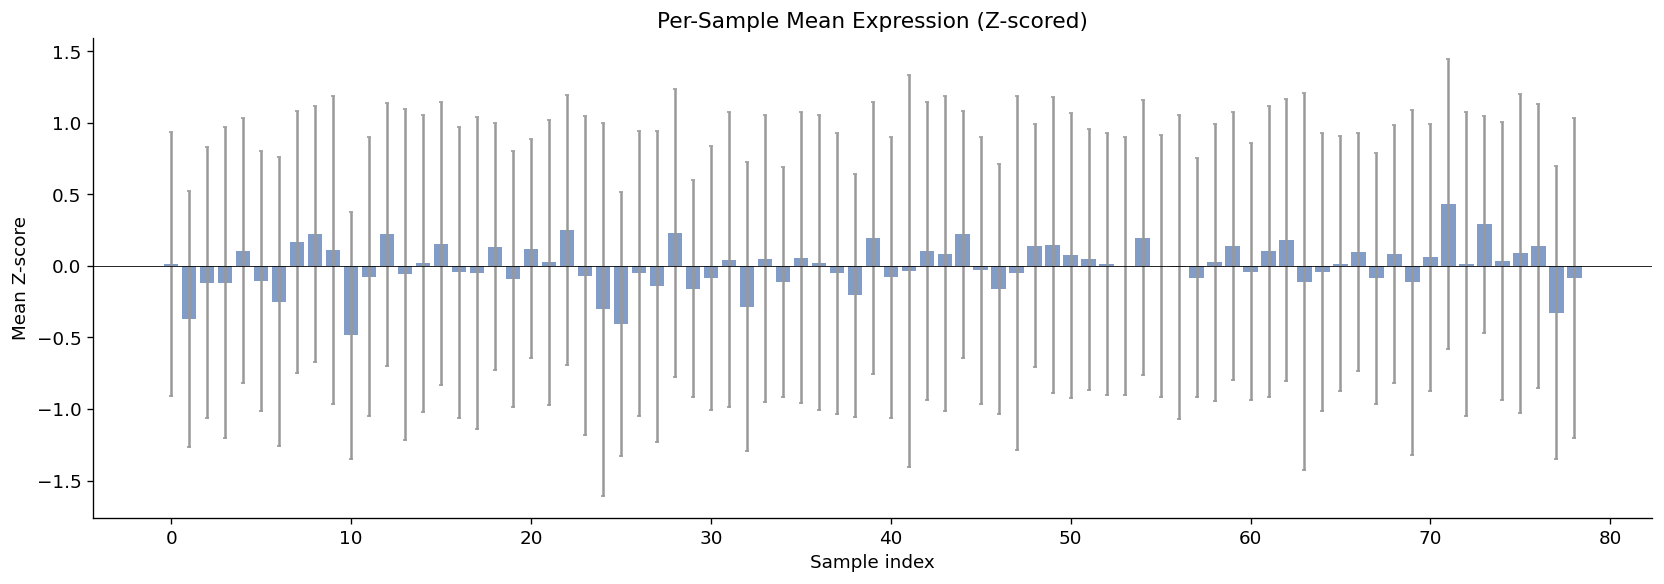

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
sample_means = X_scaled.mean(axis=1)
sample_stds = X_scaled.std(axis=1)
x_pos = range(len(sample_means))
ax.bar(x_pos, sample_means.values, yerr=sample_stds.values,
       color="#4C72B0", alpha=0.7, ecolor="#999999", capsize=1)
ax.set(title="Per-Sample Mean Expression (Z-scored)", xlabel="Sample index", ylabel="Mean Z-score")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_sample_expression.png", dpi=150, bbox_inches="tight")
plt.show()

### 10b. Correlation Heatmap (Top 50 Genes)

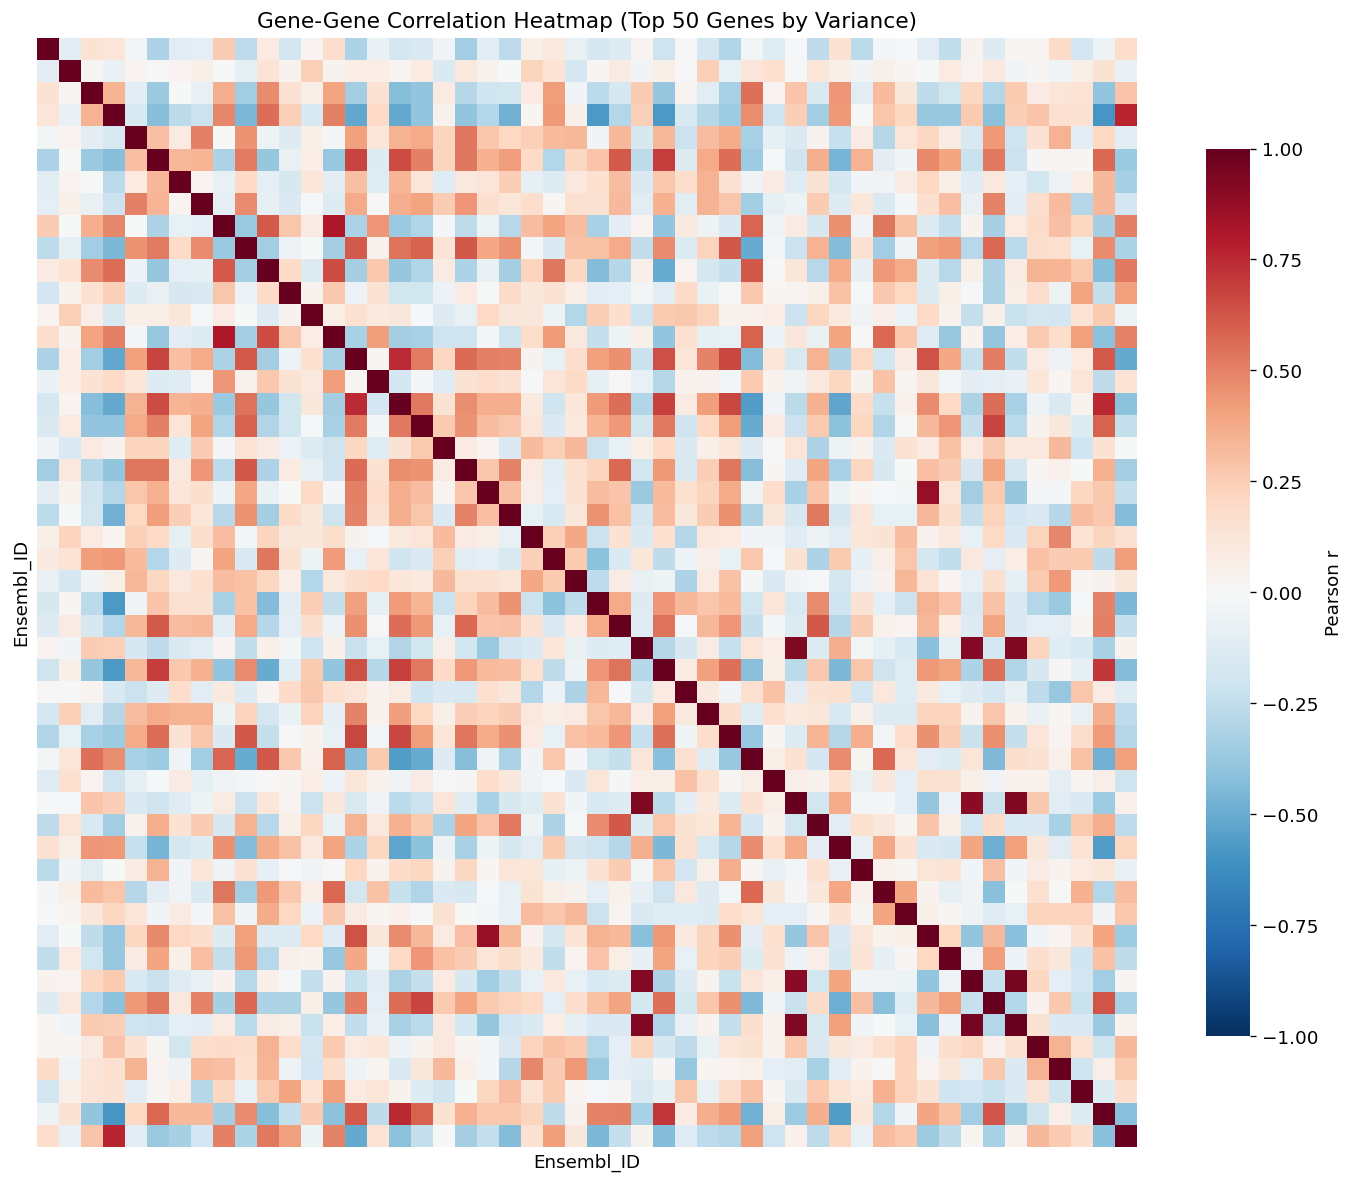

In [14]:
top50 = X_scaled.iloc[:, :50]
corr = top50.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, ax=ax,
            cbar_kws={"label": "Pearson r", "shrink": 0.8})
ax.set_title("Gene-Gene Correlation Heatmap (Top 50 Genes by Variance)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "gene_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 10c. Class Distribution & Clinical Overview

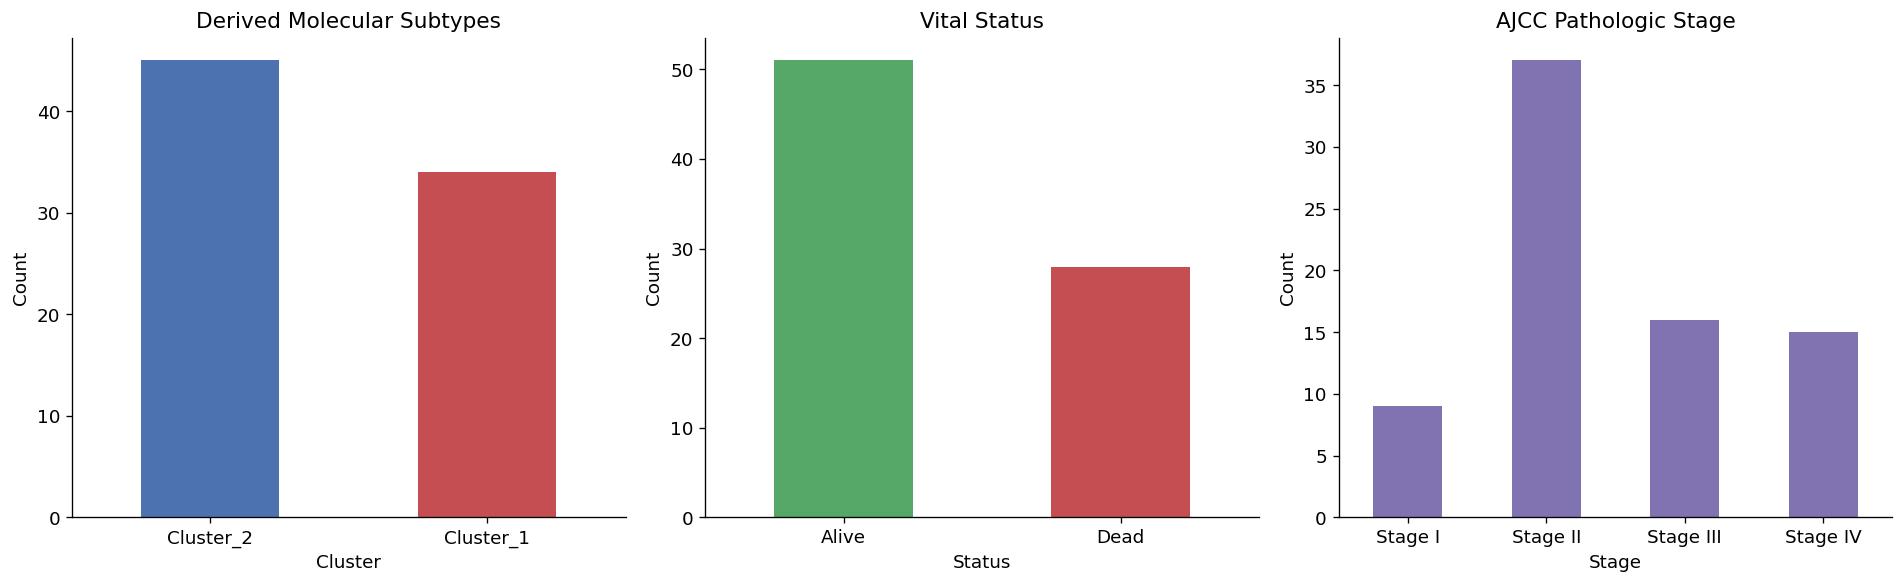

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cluster distribution
y_named.value_counts().plot.bar(ax=axes[0], color=["#4C72B0", "#C44E52"], edgecolor="none")
axes[0].set(title="Derived Molecular Subtypes", xlabel="Cluster", ylabel="Count")
axes[0].tick_params(axis="x", rotation=0)

# Vital status  (clin is already indexed by sample from Section 2c)
clin_aligned = clin.loc[X.index].copy()
if "vital_status.demographic" in clin_aligned.columns:
    clin_aligned["vital_status.demographic"].value_counts().plot.bar(
        ax=axes[1], color=["#55A868", "#C44E52"], edgecolor="none")
    axes[1].set(title="Vital Status", xlabel="Status", ylabel="Count")
    axes[1].tick_params(axis="x", rotation=0)

# AJCC Stage
if "ajcc_pathologic_stage.diagnoses" in clin_aligned.columns:
    stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]
    stage_counts = clin_aligned["ajcc_pathologic_stage.diagnoses"].value_counts()
    stage_counts = stage_counts.reindex(stage_order).dropna()
    stage_counts.plot.bar(ax=axes[2], color="#8172B2", edgecolor="none")
    axes[2].set(title="AJCC Pathologic Stage", xlabel="Stage", ylabel="Count")
    axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "clinical_overview.png", dpi=150, bbox_inches="tight")
plt.show()

### 10d. Cluster vs. Clinical Associations

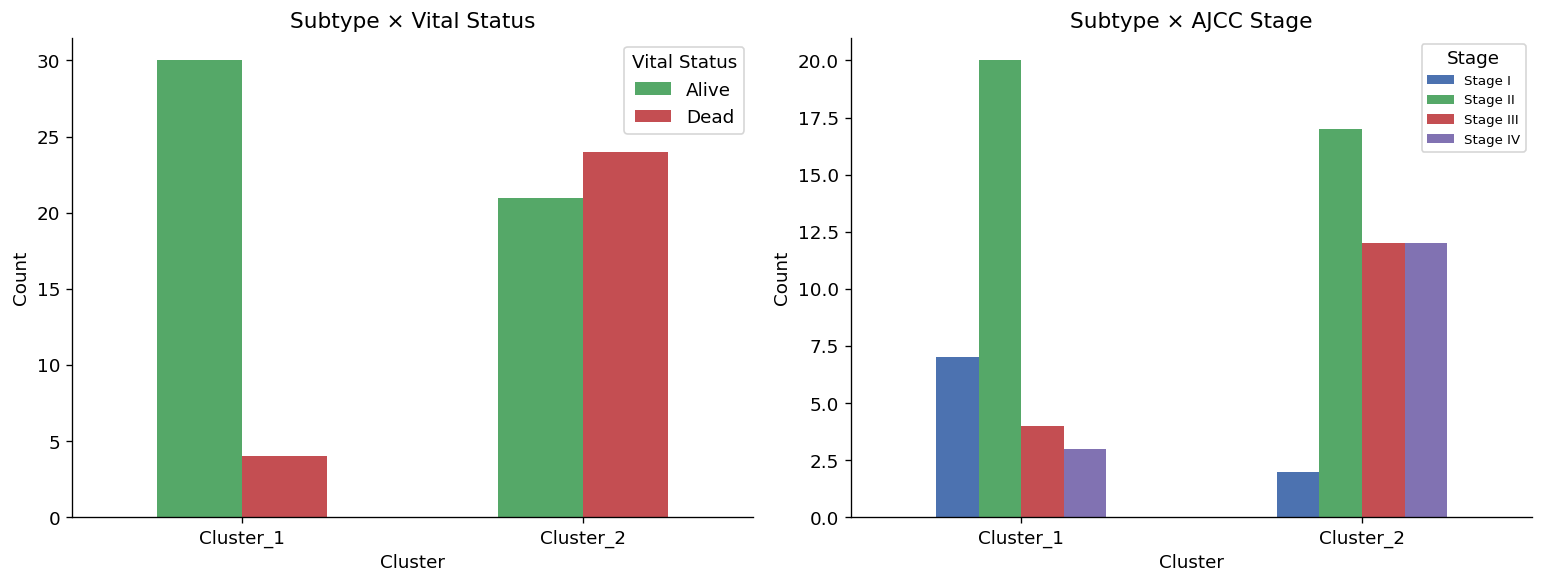

In [16]:
clin_aligned["subtype"] = y_named.values

# Subtype × Vital Status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
if "vital_status.demographic" in clin_aligned.columns:
    ct = pd.crosstab(clin_aligned["subtype"], clin_aligned["vital_status.demographic"])
    ct.plot.bar(ax=axes[0], color=["#55A868", "#C44E52"], edgecolor="none")
    axes[0].set(title="Subtype × Vital Status", xlabel="Cluster", ylabel="Count")
    axes[0].legend(title="Vital Status")
    axes[0].tick_params(axis="x", rotation=0)

# Subtype × Stage
if "ajcc_pathologic_stage.diagnoses" in clin_aligned.columns:
    ct2 = pd.crosstab(clin_aligned["subtype"], clin_aligned["ajcc_pathologic_stage.diagnoses"])
    ct2.plot.bar(ax=axes[1], color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"], edgecolor="none")
    axes[1].set(title="Subtype × AJCC Stage", xlabel="Cluster", ylabel="Count")
    axes[1].legend(title="Stage", fontsize=8)
    axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cluster_clinical_associations.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Save Processed Data
Save the clean, normalized feature matrix, raw (pre-normalization) matrix,
target labels, and aligned clinical data for downstream modeling.

In [17]:
# 11a. Normalized feature matrix (samples × genes) — for ML
X_scaled.to_csv(PROCESSED_DIR / "X_normalized.csv")
print(f"✓ Saved: X_normalized.csv  {X_scaled.shape}")

# 11b. Log2-transformed, filtered (pre-normalization) matrix — for SHAP interpretation
X.to_csv(PROCESSED_DIR / "X_log2_filtered.csv")
print(f"✓ Saved: X_log2_filtered.csv  {X.shape}")

# 11c. Target labels
y_df = pd.DataFrame({"cluster_id": y, "subtype": y_named}, index=y.index)
y_df.index.name = "sample_id"
y_df.to_csv(PROCESSED_DIR / "y_labels.csv")
print(f"✓ Saved: y_labels.csv  {y_df.shape}")

# 11d. Aligned clinical data (index name = sample)
clin_aligned.index.name = "sample"
clin_aligned.to_csv(PROCESSED_DIR / "clinical_aligned.csv")
print(f"✓ Saved: clinical_aligned.csv  {clin_aligned.shape}")

# 11e. Gene list (ordered by variance)
gene_list = pd.DataFrame({
    "ensembl_id": expr_top.index,
    "variance": expr_top.var(axis=1).values,
}).sort_values("variance", ascending=False)
gene_list.to_csv(PROCESSED_DIR / "gene_list_top2000.csv", index=False)
print(f"✓ Saved: gene_list_top2000.csv  {gene_list.shape}")

# 11f. Pipeline metadata
import json
metadata = {
    "pipeline_version": "1.0",
    "n_samples": int(X_scaled.shape[0]),
    "n_features": int(X_scaled.shape[1]),
    "log2_transform": True,
    "cv_threshold": 0.1,
    "top_k_genes": TOP_K,
    "genes_after_cv_filter": int(expr_filtered.shape[0]),
    "clustering_method": "KMeans(k=2, PCA 90% variance)",
    "pca_components_used": int(pca.n_components_),
    "silhouette_score": round(float(sil_score), 4),
    "class_distribution": class_counts.to_dict(),
    "smote_needed": smote_applied,
    "normalization": "Z-score (StandardScaler)",
    "random_seed": SEED,
}
with open(PROCESSED_DIR / "preprocessing_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved: preprocessing_metadata.json")

✓ Saved: X_normalized.csv  (79, 2000)
✓ Saved: X_log2_filtered.csv  (79, 2000)


✓ Saved: y_labels.csv  (79, 2)
✓ Saved: clinical_aligned.csv  (79, 82)
✓ Saved: gene_list_top2000.csv  (2000, 2)
✓ Saved: preprocessing_metadata.json


## Summary
| Step | Result |
|------|--------|
| Raw genes | 60,660 |
| After ENSEMBL cleaning | see above |
| After CV < 0.1 filter | see above |
| Top-K selected | 2,000 |
| Derived subtypes | Cluster 1 vs Cluster 2 (k-means on PCA) |
| SMOTE | Applied inside CV folds if needed |
| Normalization | Z-score |

**Next:** `02_modeling.ipynb` — Stratified 5-fold CV with RF, XGBoost, SVM.

In [18]:
print("\n" + "=" * 60)
print("  PREPROCESSING COMPLETE")
print("=" * 60)
print(f"  Feature matrix : {X_scaled.shape[0]} samples × {X_scaled.shape[1]} genes")
print(f"  Subtypes       : {class_counts.to_dict()}")
print(f"  Silhouette     : {sil_score:.4f}")
print(f"  Output dir     : {PROCESSED_DIR}")
print("=" * 60)


  PREPROCESSING COMPLETE
  Feature matrix : 79 samples × 2000 genes
  Subtypes       : {'Cluster_2': 45, 'Cluster_1': 34}
  Silhouette     : 0.1313
  Output dir     : E:\Research Paper\ACC\data\processed
